<h1 style="color: #1a73e8; text-align: center">PhishAegis { Malicious URLs Detection System }</h1>
<h3 style="text-align: center; color: #5f6368">Hybrid Machine Learning + Deep Learning Architecture</h3>
<hr>

## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, KFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_curve, auc)
import xgboost as xgb
import joblib

import sys, os
sys.path.append(os.path.abspath("."))
from src.extraction import extract_features, get_feature_names
from src.deep_model import urls_to_sequences, build_cnn_model, normalize_url

## 2. Loading the Dataset

In [2]:
data = pd.read_csv("Dataset.csv")
data.head(10)

,url,label
0,br-icloud.com.br,malicious
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,malicious
4,http://adventure-nicaragua.net/index.php?optio...,malicious
5,http://buzzfil.net/m/show-art/ils-etaient-loin...,benign
6,espn.go.com/nba/player/_/id/3457/brandon-rush,benign
7,yourbittorrent.com/?q=anthony-hamilton-soulife,benign
8,http://www.pashminaonline.com/pure-pashminas,malicious
9,allmusic.com/album/crazy-from-the-heat-r16990,benign


In [3]:
data.shape

(651196, 2)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 651196 entries, 0 to 651195
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   url     651196 non-null  object
 1   label   651196 non-null  object
dtypes: object(2)
memory usage: 9.9+ MB


## 3. Dataset Bias Correction

**Important:** The raw `Dataset.csv` has biases. For example, 94% of `github.com` URLs in it are labeled malicious, and 86% of `.tk` URLs are labeled benign. We inject a small correction dataset of known safe domains and known malicious patterns to fix these blindspots.

In [5]:
correction_urls = []
# 1. Force model to learn these are SAFE
safe_domains = ['github.com/user/repo', 'wikipedia.org/wiki/page', 'google.com/search?q=test', 
                'stackoverflow.com/questions/123', 'amazon.com/dp/123']
for domain in safe_domains:
    for i in range(100):  # Add 100 variations of each
        correction_urls.append({'url': f"https://www.{domain}{i}", 'label': 'benign'})

# 2. Force model to learn these are MALICIOUS
malicious_tlds = ['.tk', '.ml', '.ga', '.cf', '.gq']
for tld in malicious_tlds:
    for i in range(100):
        correction_urls.append({'url': f"http://free-prize-claim{i}{tld}/login", 'label': 'malicious'})

correction_df = pd.DataFrame(correction_urls)
data = pd.concat([data, correction_df], ignore_index=True)
print(f"Injected {len(correction_df)} correction URLs.")

Injected 1000 correction URLs.


## 4. Exploratory Data Analysis

### 4.1 Class Distribution

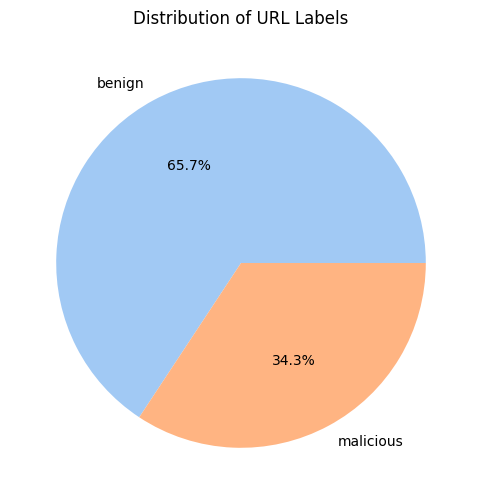

In [6]:
plt.figure(figsize=(6, 6))
plt.pie(data['label'].value_counts(),
        labels=data['label'].value_counts().index,
        autopct='%1.1f%%',
        colors=sns.color_palette("pastel"))
plt.title('Distribution of URL Labels')
plt.show()

### 4.2 Remove Duplicate URLs

In [7]:
print("Duplicates before cleaning:", data.duplicated(subset=['url']).sum())
data = data.drop_duplicates(subset=['url', 'label'], keep='first')
dup_conflict = data[data.duplicated(subset=['url'], keep=False)]
data = data.drop(dup_conflict.index)
print("Dataset shape after cleaning:", data.shape)

Duplicates before cleaning: 10072
Dataset shape after cleaning: (642118, 2)


## 5. Balanced Dataset Sampling & Feature Extraction

We draw a balanced sample of **75,000 benign** and **75,000 malicious** URLs (150,000 total clean samples)
from the dataset and extract 16 normalized lexical features.

In [8]:
sample_size = 75000
benign_sample    = data[data['label'] == 'benign'].sample(n=sample_size, random_state=42)
malicious_sample = data[data['label'] == 'malicious'].sample(n=sample_size, random_state=42)

# Ensure our corrections are definitely in the training set
corrections = data.tail(len(correction_df))
df = pd.concat([benign_sample, malicious_sample, corrections]).drop_duplicates(subset=['url']).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Working dataset: {df.shape[0]} rows")
print(df['label'].value_counts())

Working dataset: 150753 rows
label
benign       75410
malicious    75343
Name: count, dtype: int64


In [9]:
print("Extracting 16 Lexical features...")
feat_rows = [extract_features(u) for u in df['url']]
X = pd.DataFrame(feat_rows)[get_feature_names()]
y = df['label'].map({'benign': 0, 'malicious': 1})
print("Feature matrix shape:", X.shape)
X.head()

Extracting 16 Lexical features...
Feature matrix shape: (150753, 16)


,url_len,hostname_length,num_special_chars,domain_entropy,digit_count,letter_count,digit_ratio,use_of_ip,has_shortening_service,has_javascript_code,has_text_encoding,path_depth,subdomain_count,has_at_symbol,suspicious_tld,abnormal_url
0,15,9,2,2.947703,0,12,0.000000,0,0,0,0,1,0,0,0,0
1,50,12,3,2.918296,0,42,0.000000,0,0,0,0,4,1,0,0,0
2,11,6,1,2.251629,1,7,0.090909,0,0,0,0,1,0,0,0,0
3,28,11,2,2.913977,0,24,0.000000,0,0,0,0,2,0,0,0,0
4,27,16,2,3.327820,0,23,0.000000,0,0,0,0,2,1,0,0,0


## 6. Train / Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Also split the raw URLs for the Deep Learning model
urls_train = df.loc[X_train.index, 'url']
urls_test  = df.loc[X_test.index, 'url']

print(f"Train: {X_train.shape}   Test: {X_test.shape}")

Train: (120602, 16)   Test: (30151, 16)


## 7. Training ML Models

Training Logistic Regression, Random Forest, XGBoost, and a Voting ML Ensemble.

In [11]:
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]
print(f"Logistic Regression : {accuracy_score(y_test, lr_pred):.4f}")

Training Logistic Regression...
Logistic Regression : 0.5870


In [12]:
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=300, max_depth=25, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]
print(f"Random Forest       : {accuracy_score(y_test, rf_pred):.4f}")

Training Random Forest...
Random Forest       : 0.8370


In [13]:
print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
print(f"XGBoost             : {accuracy_score(y_test, xgb_pred):.4f}")

Training XGBoost...
XGBoost             : 0.8266


In [14]:
print("Building Voting ML Ensemble...")
ensemble = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb_model)],
    voting='soft'
)
ensemble.fit(X_train, y_train)
ens_pred = ensemble.predict(X_test)
ens_prob = ensemble.predict_proba(X_test)[:, 1]
print(f"ML Ensemble (RF+XGB): {accuracy_score(y_test, ens_pred):.4f}")

Building Voting ML Ensemble...
ML Ensemble (RF+XGB): 0.8398


## 8. Deep Learning — Character-Level CNN (GPU Accelerated)

The CNN reads the **raw characters** of each URL through parallel 1D convolutional filters (sizes 3, 5, 7),
learning microscopic structural patterns with SpatialDropout and L2 regularization.

In [15]:
# Convert URLs to character sequences
print("Converting URLs to character sequences...")
X_seq_train = urls_to_sequences(urls_train)
X_seq_test  = urls_to_sequences(urls_test)
print(f"Sequence shape: Train={X_seq_train.shape}, Test={X_seq_test.shape}")

Converting URLs to character sequences...
Sequence shape: Train=(120602, 200), Test=(30151, 200)


In [16]:
# Build CNN model
print("Building Character-Level CNN...")
cnn_model = build_cnn_model()
cnn_model.summary()

Building Character-Level CNN...
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 200)]        0           []                               
                                                                                                  
 embedding (Embedding)          (None, 200, 64)      6208        ['input_1[0][0]']                
                                                                                                  
 spatial_dropout1d (SpatialDrop  (None, 200, 64)     0           ['embedding[0][0]']              
 out1D)                                                                                           
                                                                                                  
 conv1d (Conv1D)                (None, 200, 128)     24704    

In [17]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

cnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
]

print("Training CNN with GPU acceleration...")
history = cnn_model.fit(
    X_seq_train, y_train.values,
    validation_data=(X_seq_test, y_test.values),
    epochs=15,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

Training CNN with GPU acceleration...
Epoch 1/15
472/472 [==============================] - 21s 42ms/step - loss: 0.8762 - accuracy: 0.8092 - val_loss: 0.4767 - val_accuracy: 0.8269 - lr: 0.0010
Epoch 2/15
472/472 [==============================] - 19s 41ms/step - loss: 0.3306 - accuracy: 0.8784 - val_loss: 0.2722 - val_accuracy: 0.8969 - lr: 0.0010
Epoch 3/15
472/472 [==============================] - 19s 41ms/step - loss: 0.2846 - accuracy: 0.8926 - val_loss: 0.2460 - val_accuracy: 0.9050 - lr: 0.0010
Epoch 4/15
472/472 [==============================] - 19s 41ms/step - loss: 0.2612 - accuracy: 0.9021 - val_loss: 0.2452 - val_accuracy: 0.9060 - lr: 0.0010
Epoch 5/15
472/472 [==============================] - 19s 41ms/step - loss: 0.2450 - accuracy: 0.9080 - val_loss: 0.2359 - val_accuracy: 0.9071 - lr: 0.0010
Epoch 6/15
472/472 [==============================] - 19s 41ms/step - loss: 0.2380 - accuracy: 0.9118 - val_loss: 0.2420 - val_accuracy: 0.8977 - lr: 0.0010
Epoch 7/15
472/472 [

### 8.1 CNN Training History

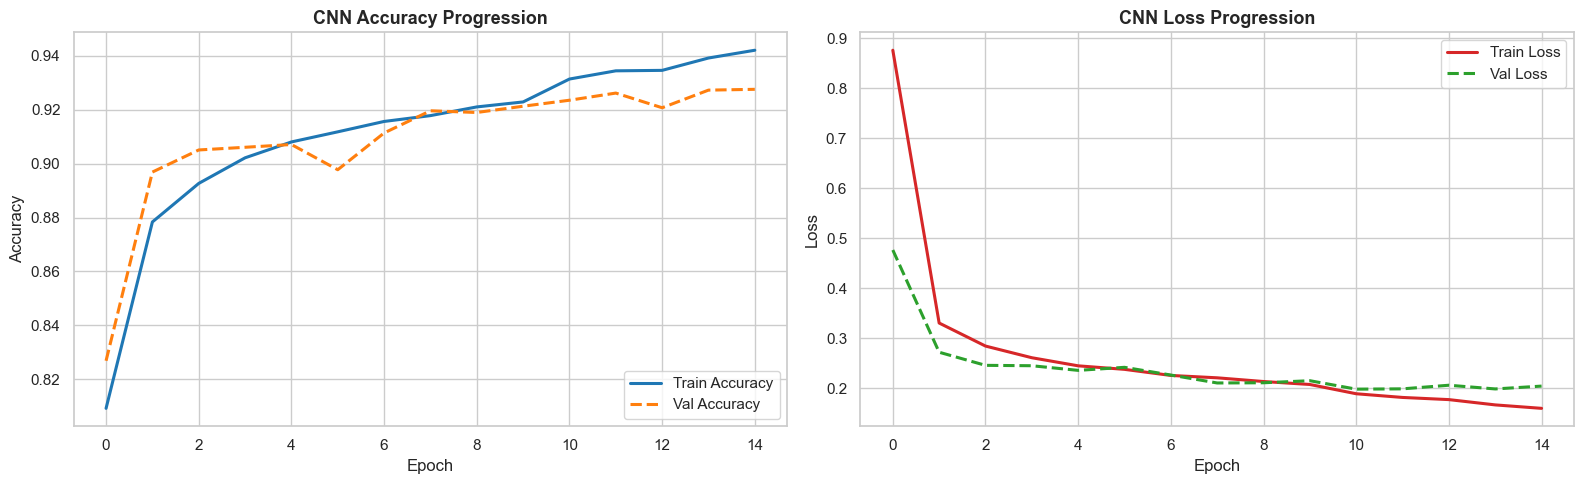

In [18]:
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Accuracy Plot
ax1.plot(history.history['accuracy'], label='Train Accuracy', color='#1f77b4', linewidth=2.2)
ax1.plot(history.history['val_accuracy'], label='Val Accuracy', color='#ff7f0e', linewidth=2.2, linestyle='--')
ax1.set_title('CNN Accuracy Progression', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend(loc='lower right', frameon=True)

# Loss Plot
ax2.plot(history.history['loss'], label='Train Loss', color='#d62728', linewidth=2.2)
ax2.plot(history.history['val_loss'], label='Val Loss', color='#2ca02c', linewidth=2.2, linestyle='--')
ax2.set_title('CNN Loss Progression', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

In [19]:
# CNN predictions
cnn_prob = cnn_model.predict(X_seq_test, verbose=0).flatten()
cnn_pred = (cnn_prob >= 0.5).astype(int)
cnn_acc = accuracy_score(y_test, cnn_pred)
print(f"CNN Accuracy: {cnn_acc:.4f}")
print(classification_report(y_test, cnn_pred, target_names=['Benign', 'Malicious']))

CNN Accuracy: 0.9235
              precision    recall  f1-score   support

      Benign       0.93      0.91      0.92     15082
   Malicious       0.91      0.94      0.92     15069

    accuracy                           0.92     30151
   macro avg       0.92      0.92      0.92     30151
weighted avg       0.92      0.92      0.92     30151



## 9. Final Hybrid Model — ML Ensemble + Deep Learning CNN

A meta-ensemble combining hand-crafted lexical feature intelligence with deep character-level embeddings.
Because the Deep Learning CNN handles the large dataset much better (higher model capacity), we use a weighted average favoring the CNN (85%).

In [20]:
# Weighted average probabilities (15% ML, 85% CNN)
hybrid_prob = (0.15 * ens_prob) + (0.85 * cnn_prob)
hybrid_pred = (hybrid_prob >= 0.5).astype(int)

hybrid_acc = accuracy_score(y_test, hybrid_pred)
print(f"\nFinal Hybrid (ML + CNN) Accuracy: {hybrid_acc:.4f}")
print(f"\nComparison:")
print(f"  Logistic Regression : {accuracy_score(y_test, lr_pred):.4f}")
print(f"  Random Forest       : {accuracy_score(y_test, rf_pred):.4f}")
print(f"  XGBoost             : {accuracy_score(y_test, xgb_pred):.4f}")
print(f"  ML Ensemble (RF+XGB): {accuracy_score(y_test, ens_pred):.4f}")
print(f"  CNN (Deep Learning) : {cnn_acc:.4f}")
print(f"  HYBRID (ML + CNN)   : {hybrid_acc:.4f}  <--- BEST")


Final Hybrid (ML + CNN) Accuracy: 0.9249

Comparison:
  Logistic Regression : 0.5870
  Random Forest       : 0.8370
  XGBoost             : 0.8266
  ML Ensemble (RF+XGB): 0.8398
  CNN (Deep Learning) : 0.9235
  HYBRID (ML + CNN)   : 0.9249  <--- BEST


### 9.1 All Models Accuracy Comparison

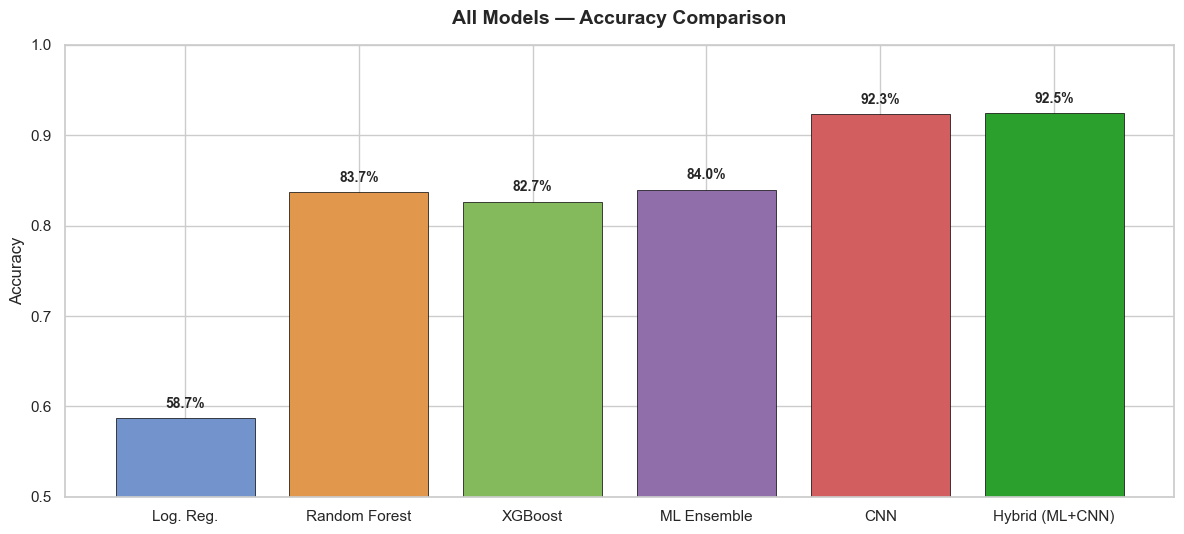

In [21]:
model_names = ['Log. Reg.', 'Random Forest', 'XGBoost', 'ML Ensemble', 'CNN', 'Hybrid (ML+CNN)']
accuracies  = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, xgb_pred),
    accuracy_score(y_test, ens_pred),
    cnn_acc,
    hybrid_acc
]

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5.5))
colors = ['#7293CB', '#E1974C', '#84BA5B', '#906EA9', '#D35E60', '#2ca02c']
bars = plt.bar(model_names, accuracies, color=colors, edgecolor='black', linewidth=0.5)
plt.ylim(0.50, 1.0)
plt.ylabel('Accuracy', fontsize=12)
plt.title('All Models — Accuracy Comparison', fontsize=14, fontweight='bold', pad=15)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
             f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 10. Classification Reports

In [22]:
all_models = {
    'Logistic Regression': lr_pred,
    'Random Forest':       rf_pred,
    'XGBoost':             xgb_pred,
    'ML Ensemble (RF+XGB)': ens_pred,
    'CNN (Deep Learning)': cnn_pred,
    'HYBRID (ML + CNN)':   hybrid_pred,
}
for name, preds in all_models.items():
    print(f"{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(classification_report(y_test, preds, target_names=['Benign', 'Malicious']))

  Logistic Regression
              precision    recall  f1-score   support

      Benign       0.58      0.63      0.60     15082
   Malicious       0.59      0.55      0.57     15069

    accuracy                           0.59     30151
   macro avg       0.59      0.59      0.59     30151
weighted avg       0.59      0.59      0.59     30151

  Random Forest
              precision    recall  f1-score   support

      Benign       0.83      0.84      0.84     15082
   Malicious       0.84      0.83      0.84     15069

    accuracy                           0.84     30151
   macro avg       0.84      0.84      0.84     30151
weighted avg       0.84      0.84      0.84     30151

  XGBoost
              precision    recall  f1-score   support

      Benign       0.83      0.83      0.83     15082
   Malicious       0.83      0.82      0.83     15069

    accuracy                           0.83     30151
   macro avg       0.83      0.83      0.83     30151
weighted avg       0.83   

## 11. Save All Models

In [23]:
os.makedirs('models', exist_ok=True)
joblib.dump(rf,        'models/rf_model.joblib')
joblib.dump(xgb_model, 'models/xgb_model.joblib')
joblib.dump(lr,        'models/lr_model.joblib')
joblib.dump(ensemble,  'models/ensemble_model.joblib')

# Save the CNN model
cnn_model.save('models/cnn_model.keras')

print("All models saved successfully:")
print("  - models/lr_model.joblib")
print("  - models/rf_model.joblib")
print("  - models/xgb_model.joblib")
print("  - models/ensemble_model.joblib")
print("  - models/cnn_model.keras")

All models saved successfully:
  - models/lr_model.joblib
  - models/rf_model.joblib
  - models/xgb_model.joblib
  - models/ensemble_model.joblib
  - models/cnn_model.keras


## 12. Real-World Inference Test

Testing the **Hybrid model** (ML Ensemble + CNN) on sample URLs.

In [24]:
test_urls = [
    ("https://www.google.com/search?q=python",         "should be SAFE"),
    ("https://en.wikipedia.org/wiki/Machine_learning",  "should be SAFE"),
    ("https://stackoverflow.com/questions",             "should be SAFE"),
    ("https://github.com/tensorflow/tensorflow",        "should be SAFE"),
    ("http://192.168.1.1/login.php?update=true",        "should be MALICIOUS (raw IP)"),
    ("http://bit.ly/3xAbc12",                           "should be MALICIOUS (shortener)"),
    ("http://paypa1-secure-login.com/verify?user=admin", "should be MALICIOUS (typosquat)"),
    ("http://free-iphone.tk/claim?id=123",              "should be MALICIOUS (suspicious TLD)"),
]

print("Hybrid Model (ML Ensemble + CNN) Inference Test:")
print("-" * 90)
for url, note in test_urls:
    # ML Ensemble prediction
    feats = extract_features(url)
    feat_row = pd.DataFrame([feats])[get_feature_names()]
    ml_prob = ensemble.predict_proba(feat_row)[0][1]
    
    # CNN prediction
    seq = urls_to_sequences([url])
    cnn_p = float(cnn_model.predict(seq, verbose=0)[0][0])
    
    # Hybrid weighted average (85% CNN)
    hybrid_p = (0.15 * ml_prob) + (0.85 * cnn_p)
    label = "MALICIOUS" if hybrid_p > 0.5 else "SAFE"
    print(f"[{label:9s}] risk={hybrid_p*100:5.1f}%  (ML={ml_prob*100:.0f}%, CNN={cnn_p*100:.0f}%)  | {note}")

Hybrid Model (ML Ensemble + CNN) Inference Test:
------------------------------------------------------------------------------------------
[SAFE     ] risk=  6.4%  (ML=32%, CNN=2%)  | should be SAFE
[SAFE     ] risk= 10.8%  (ML=7%, CNN=11%)  | should be SAFE
[SAFE     ] risk= 13.8%  (ML=57%, CNN=6%)  | should be SAFE
[SAFE     ] risk= 44.6%  (ML=44%, CNN=45%)  | should be SAFE
[MALICIOUS] risk= 98.3%  (ML=91%, CNN=100%)  | should be MALICIOUS (raw IP)
[MALICIOUS] risk= 67.5%  (ML=75%, CNN=66%)  | should be MALICIOUS (shortener)
[MALICIOUS] risk= 91.9%  (ML=57%, CNN=98%)  | should be MALICIOUS (typosquat)
[MALICIOUS] risk= 97.4%  (ML=90%, CNN=99%)  | should be MALICIOUS (suspicious TLD)
